In [ ]:
!pip install librosa

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 00b01445_nohash_0.wav to 00b01445_nohash_0 (1).wav


In [ ]:
sound = '00b01445_nohash_0.wav'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
!pip install librosa

In [ ]:
import IPython.display as ipd
import librosa
y, sr = librosa.load(sound) #y-sound sr-time
display(ipd.Audio(y, rate=sr))

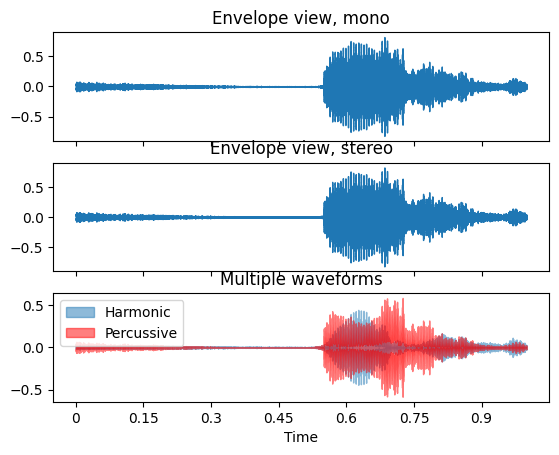

In [ ]:
y, sr = librosa.load(sound)
fig, ax = plt.subplots(nrows=3, sharex=True)
librosa.display.waveshow(y, sr=sr, ax=ax[0])
ax[0].set(title='Envelope view, mono')
ax[0].label_outer()
librosa.display.waveshow(y, sr=sr, ax=ax[1])
ax[1].set(title='Envelope view, stereo')
ax[1].label_outer()
y_harm, y_perc = librosa.effects.hpss(y)
librosa.display.waveshow(y_harm, sr=sr, alpha=0.5, ax=ax[2], label='Harmonic')
librosa.display.waveshow(y_perc, sr=sr, color='r', alpha=0.5, ax=ax[2], label='Percussive')
ax[2].set(title='Multiple waveforms')
ax[2].legend()

In [ ]:
D = np.abs(librosa.stft(y))**2
S = librosa.feature.melspectrogram(S=D, sr=sr)

In [ ]:
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128,
                                    fmax=8000)

[Text(0.5, 1.0, 'Mel-frequency spectrogram')]

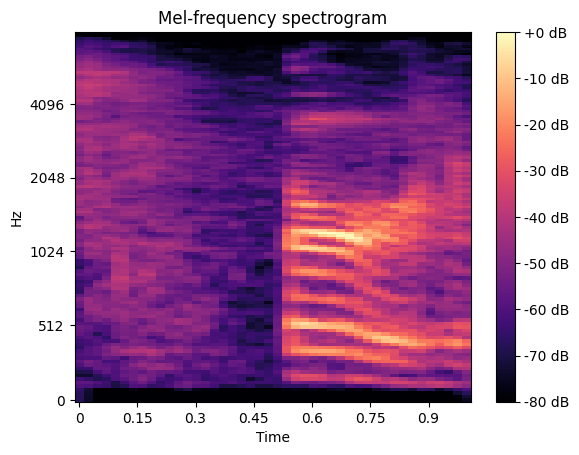

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
S_dB = librosa.power_to_db(S, ref=np.max)
img = librosa.display.specshow(S_dB, x_axis='time',
                         y_axis='mel', sr=sr,
                         fmax=8000, ax=ax)
fig.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set(title='Mel-frequency spectrogram')

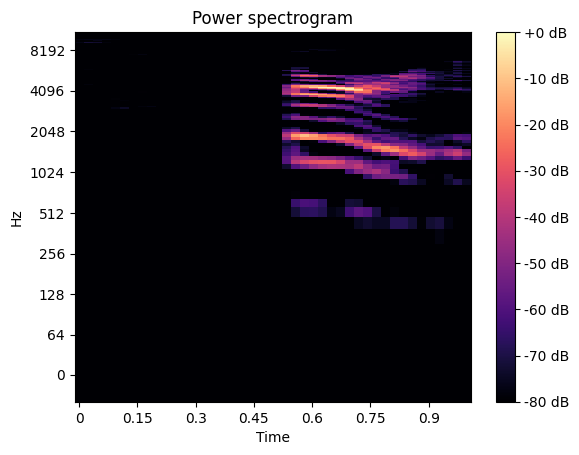

In [ ]:
fig, ax = plt.subplots()
img = librosa.display.specshow(librosa.amplitude_to_db(S,
                                                       ref=np.max),
                               y_axis='log', x_axis='time', ax=ax)
ax.set_title('Power spectrogram')
fig.colorbar(img, ax=ax, format="%+2.0f dB")

In [ ]:
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

[Text(0.5, 1.0, 'MFCC')]

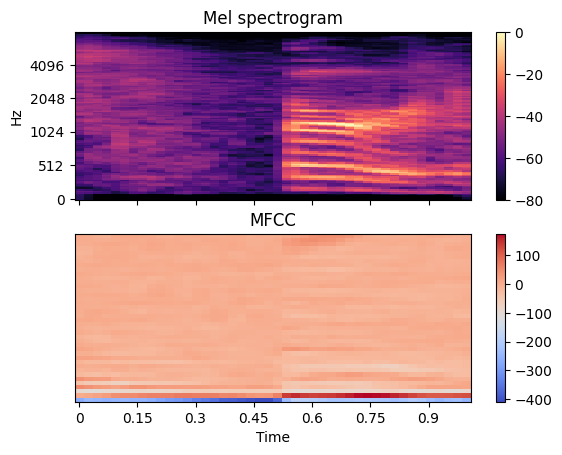

In [ ]:
fig, ax = plt.subplots(nrows=2, sharex=True)
img = librosa.display.specshow(librosa.power_to_db(S, ref=np.max),
                               x_axis='time', y_axis='mel', fmax=8000,
                               ax=ax[0])
fig.colorbar(img, ax=[ax[0]])
ax[0].set(title='Mel spectrogram')
ax[0].label_outer()
img = librosa.display.specshow(mfccs, x_axis='time', ax=ax[1])
fig.colorbar(img, ax=[ax[1]])
ax[1].set(title='MFCC')

In [ ]:
!pip install audiomentations

In [ ]:
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift, Shift

In [ ]:
augment = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.5),
    TimeStretch(min_rate=0.8, max_rate=1.25, p=0.5),
    PitchShift(min_semitones=-4, max_semitones=4, p=0.5),
    Shift(p=0.5),
])

augmented_samples = augment(samples=y, sample_rate=sr)

In [ ]:
display(augmented_samples)

array([ 0.00300411, -0.00922775, -0.01724356, ..., -0.00432999,
        0.00246863, -0.00358895], dtype=float32)

In [ ]:
display(ipd.Audio(y, rate=sr))

In [ ]:
display(ipd.Audio(augmented_samples, rate=sr))

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Animals.zip to Animals.zip


In [ ]:
import zipfile
import os
import shutil

with zipfile.ZipFile('Animals.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

source = '/content/dataset/Animals'
destination = '/content/dataset'

for item in os.listdir(source):
    shutil.move(os.path.join(source, item), destination)

os.rmdir(source)

!ls /content/dataset

bird  cat  dog


In [ ]:
import random
from sklearn.model_selection import train_test_split

base_dir = '/content/dataset'
output_dir = '/content/split_dataset'

for split in ['train', 'test']:
    for cls in ['bird', 'cat', 'dog']:
        os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

all_files = {'bird': [], 'cat': [], 'dog': []}
for cls in all_files.keys():
    cls_path = os.path.join(base_dir, cls)
    files = [os.path.join(cls_path, f) for f in os.listdir(cls_path) if f.endswith(('.wav', '.mp3', '.flac'))]
    all_files[cls] = files

test_size = 0.2
random_state = 42

for cls, files in all_files.items():
    train_files, test_files = train_test_split(files, test_size=test_size, random_state=random_state)

    for f in train_files:
        shutil.copy(f, os.path.join(output_dir, 'train', cls, os.path.basename(f)))
    for f in test_files:
        shutil.copy(f, os.path.join(output_dir, 'test', cls, os.path.basename(f)))

In [ ]:
!find /content/split_dataset -type f | wc -l

610


In [ ]:
!echo "Train:" && ls /content/split_dataset/train/*/* | wc -l
!echo "Test:" && ls /content/split_dataset/test/*/* | wc -l

Train:
487
Test:
123


In [ ]:
SR = 22050
SAMPLE_DURATION = 1
MAX_LEN_SAMPLES = 22050 #(SR * SAMPLE_DURATION)
hop_length = 512
MAX_LEN_TIME_FRAMES = 44 #(SR * SAMPLE_DURATION) // hop_length + 1
N_MELS = 64
N_MFCC = 20

In [ ]:
def extract_waveform(y, max_len):
    if len(y) >= max_len:
        return y[:max_len]
    else:
        return np.pad(y, (0, max_len - len(y)))

def extract_mel(y, sr, n_mels, max_frames):
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    if mel_db.shape[1] >= max_frames:
        return mel_db[:, :max_frames]
    else:
        pad = max_frames - mel_db.shape[1]
        return np.pad(mel_db, ((0,0), (0,pad)), mode='constant')

def extract_log_mel(y, sr, n_mels, max_frames):
    return extract_mel(y, sr, n_mels, max_frames)

def extract_mfcc(y, sr, n_mfcc, max_frames):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    if mfcc.shape[1] >= max_frames:
        return mfcc[:, :max_frames]
    else:
        pad = max_frames - mfcc.shape[1]
        return np.pad(mfcc, ((0,0), (0,pad)), mode='constant')

In [ ]:
base_dir = '/content/split_dataset'

classes = ['bird', 'cat', 'dog']
class_to_idx = {cls:i for i,cls in enumerate(classes)}

X_train_wave, X_train_mel, X_train_logmel, X_train_mfcc = [], [], [], []
y_train = []
X_test_wave, X_test_mel, X_test_logmel, X_test_mfcc = [], [], [], []
y_test = []

for split in ['train', 'test']:
    for cls in classes:
        cls_path = os.path.join(base_dir, split, cls)
        files = [f for f in os.listdir(cls_path) if f.endswith(('.wav'))]
        for fname in tqdm(files, desc=f'{split}/{cls}'):
            y, _ = librosa.load(os.path.join(cls_path, fname), sr=SR)
            wave = extract_waveform(y, MAX_LEN_SAMPLES)
            mel = extract_mel(y, SR, N_MELS, MAX_LEN_TIME_FRAMES)
            logmel = extract_log_mel(y, SR, N_MELS, MAX_LEN_TIME_FRAMES)
            mfcc = extract_mfcc(y, SR, N_MFCC, MAX_LEN_TIME_FRAMES)
            if split == 'train':
                X_train_wave.append(wave)
                X_train_mel.append(mel)
                X_train_logmel.append(logmel)
                X_train_mfcc.append(mfcc)
                y_train.append(class_to_idx[cls])
            else:
                X_test_wave.append(wave)
                X_test_mel.append(mel)
                X_test_logmel.append(logmel)
                X_test_mfcc.append(mfcc)
                y_test.append(class_to_idx[cls])

test/dog: 100%|██████████| 42/42 [00:00<00:00, 65.46it/s]


In [ ]:
X_train_wave = extract_wavelet_features(np.array(X_train_wave))
X_test_wave  = extract_wavelet_features(np.array(X_test_wave))

X_train_mel = np.array(X_train_mel).reshape(-1, N_MELS * MAX_LEN_TIME_FRAMES)
X_test_mel  = np.array(X_test_mel).reshape(-1, N_MELS * MAX_LEN_TIME_FRAMES)

X_train_logmel = np.array(X_train_logmel).reshape(-1, N_MELS * MAX_LEN_TIME_FRAMES)
X_test_logmel  = np.array(X_test_logmel).reshape(-1, N_MELS * MAX_LEN_TIME_FRAMES)

X_train_mfcc = np.array(X_train_mfcc).reshape(-1, N_MFCC * MAX_LEN_TIME_FRAMES)
X_test_mfcc  = np.array(X_test_mfcc).reshape(-1, N_MFCC * MAX_LEN_TIME_FRAMES)

y_train = np.array(y_train)
y_test  = np.array(y_test)

print(f"Train size: {len(y_train)}")
print(f"Test size: {len(y_test)}")

Train size: 487
Test size: 123


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=20, random_state=42, n_jobs=-1),
    'LightGBM': LGBMClassifier(objective='multiclass', num_class=3, random_state=42, verbose=-1)
}

feature_sets = {
    'Mel': (X_train_mel, X_test_mel),
    'Log-Mel': (X_train_logmel, X_test_logmel),
    'MFCC': (X_train_mfcc, X_test_mfcc),
    'Waveform': (X_train_wave, X_test_wave)
}

for feat_name, (X_tr, X_te) in feature_sets.items():
    print(f"\n{feat_name}: train shape {X_tr.shape}, test shape {X_te.shape}")
    for model_name, model in models.items():
        model_clone = model.__class__(**model.get_params())
        model_clone.fit(X_tr, y_train)
        y_pred = model_clone.predict(X_te)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        print(f"  {model_name:20} | Acc: {acc:.4f} | F1: {f1:.4f}")


Mel: train shape (487, 2816), test shape (123, 2816)
  Logistic Regression  | Acc: 0.8699 | F1: 0.8713
  Random Forest        | Acc: 0.8293 | F1: 0.8290


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LightGBM             | Acc: 0.8943 | F1: 0.8938

Log-Mel: train shape (487, 2816), test shape (123, 2816)
  Logistic Regression  | Acc: 0.8699 | F1: 0.8713
  Random Forest        | Acc: 0.8293 | F1: 0.8290


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LightGBM             | Acc: 0.8943 | F1: 0.8938

MFCC: train shape (487, 880), test shape (123, 880)
  Logistic Regression  | Acc: 0.8618 | F1: 0.8616
  Random Forest        | Acc: 0.8130 | F1: 0.8132


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LightGBM             | Acc: 0.8537 | F1: 0.8537

Waveform: train shape (487, 9), test shape (123, 9)
  Logistic Regression  | Acc: 0.3821 | F1: 0.3455
  Random Forest        | Acc: 0.5041 | F1: 0.5045
  LightGBM             | Acc: 0.4715 | F1: 0.4732


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
def augment_audio(y, sr):
    aug_type = np.random.choice(['noise', 'pitch', 'stretch'])
    if aug_type == 'noise':
        noise = np.random.normal(0, 0.005, y.shape)
        return y + noise
    elif aug_type == 'pitch':
        steps = np.random.randint(-2, 3)
        return librosa.effects.pitch_shift(y, sr=sr, n_steps=steps)
    else:
        rate = np.random.uniform(0.8, 1.2)
        y_stretched = librosa.effects.time_stretch(y, rate=rate)
        if len(y_stretched) > len(y):
            return y_stretched[:len(y)]
        else:
            return np.pad(y_stretched, (0, len(y) - len(y_stretched)))

In [ ]:
def process_dataset(base_path, augment_train=True):
    classes = {'bird':0, 'cat':1, 'dog':2}
    data = {f'{split}_{feat}': [] for split in ['train','test'] for feat in ['wave','mel','logmel','mfcc','y']}

    for split in ['train', 'test']:
        for cls, label in classes.items():
            cls_path = os.path.join(base_path, split, cls)
            files = [f for f in os.listdir(cls_path) if f.endswith(('.wav','.mp3','.flac'))]
            for fname in tqdm(files, desc=f'{split}/{cls}'):
                y, _ = librosa.load(os.path.join(cls_path, fname), sr=SR)

                wave = extract_waveform(y, MAX_LEN_SAMPLES)
                mel = extract_mel(y, SR, N_MELS, MAX_LEN_TIME_FRAMES)
                logmel = extract_log_mel(y, SR, N_MELS, MAX_LEN_TIME_FRAMES)
                mfcc = extract_mfcc(y, SR, N_MFCC, MAX_LEN_TIME_FRAMES)

                data[f'{split}_wave'].append(wave)
                data[f'{split}_mel'].append(mel)
                data[f'{split}_logmel'].append(logmel)
                data[f'{split}_mfcc'].append(mfcc)
                data[f'{split}_y'].append(label)

                if split == 'train' and augment_train:
                    y_aug = augment_audio(y, SR)
                    data[f'{split}_wave'].append(extract_waveform(y_aug, MAX_LEN_SAMPLES))
                    data[f'{split}_mel'].append(extract_mel(y_aug, SR, N_MELS, MAX_LEN_TIME_FRAMES))
                    data[f'{split}_logmel'].append(extract_log_mel(y_aug, SR, N_MELS, MAX_LEN_TIME_FRAMES))
                    data[f'{split}_mfcc'].append(extract_mfcc(y_aug, SR, N_MFCC, MAX_LEN_TIME_FRAMES))
                    data[f'{split}_y'].append(label)

    return {k: np.array(v) for k, v in data.items()}

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

def extract_wavelet_features(waveforms):

    features_list = []
    for w in waveforms:
        stats = [
            np.mean(w), np.std(w), np.max(w), np.min(w),
            np.percentile(w, 25), np.percentile(w, 50), np.percentile(w, 75),
            np.sum(w**2) / len(w),
            np.max(np.abs(w)),
        ]
        features_list.append(stats)
    return np.array(features_list)


In [ ]:
X_train_wave = extract_wavelet_features(result['train_wave'])
X_test_wave  = extract_wavelet_features(result['test_wave'])

In [ ]:
X_train_mel = result['train_mel'].reshape(result['train_mel'].shape[0], -1)
X_test_mel  = result['test_mel'].reshape(result['test_mel'].shape[0], -1)

X_train_logmel = result['train_logmel'].reshape(result['train_logmel'].shape[0], -1)
X_test_logmel  = result['test_logmel'].reshape(result['test_logmel'].shape[0], -1)

X_train_mfcc = result['train_mfcc'].reshape(result['train_mfcc'].shape[0], -1)
X_test_mfcc  = result['test_mfcc'].reshape(result['test_mfcc'].shape[0], -1)

y_train = result['train_y']
y_test  = result['test_y']

feature_sets = {
    'Waveform': (X_train_wave, X_test_wave),
    'Mel': (X_train_mel, X_test_mel),
    'Log-Mel': (X_train_logmel, X_test_logmel),
    'MFCC': (X_train_mfcc, X_test_mfcc)
}

results = {}

In [ ]:
  for name, (X_tr, X_te) in feature_sets.items():
    print(name)
    print(f"Размер train: {X_tr.shape}, test: {X_te.shape}")

    log_reg = LogisticRegression(max_iter=1000, random_state=42,
                                 multi_class='ovr', solver='liblinear', C=0.1)
    log_reg.fit(X_tr, y_train)
    y_pred = log_reg.predict(X_te)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results[name] = (acc, f1)

    print(f"Accuracy:  {acc:.4f}")
    print(f"F1 (weighted): {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=['bird','cat','dog']))

for name, (acc, f1) in results.items():
    print(f"{name:20} | Accuracy: {acc:.4f} | F1: {f1:.4f}")

Waveform
Размер train: (974, 9), test: (123, 9)
Accuracy:  0.3089
F1 (weighted): 0.2497
              precision    recall  f1-score   support

        bird       0.00      0.00      0.00        39
         cat       0.28      0.38      0.32        42
         dog       0.34      0.52      0.41        42

    accuracy                           0.31       123
   macro avg       0.20      0.30      0.24       123
weighted avg       0.21      0.31      0.25       123

Mel
Размер train: (974, 2816), test: (123, 2816)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.

Accuracy:  0.8699
F1 (weighted): 0.8699
              precision    recall  f1-score   support

        bird       0.89      0.79      0.84        39
         cat       0.81      0.90      0.85        42
         dog       0.93      0.90      0.92        42

    accuracy                           0.87       123
   macro avg       0.87      0.87      0.87       123
weighted avg       0.87      0.87      0.87       123

Log-Mel
Размер train: (974, 2816), test: (123, 2816)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy:  0.8699
F1 (weighted): 0.8699
              precision    recall  f1-score   support

        bird       0.89      0.79      0.84        39
         cat       0.81      0.90      0.85        42
         dog       0.93      0.90      0.92        42

    accuracy                           0.87       123
   macro avg       0.87      0.87      0.87       123
weighted avg       0.87      0.87      0.87       123

MFCC
Размер train: (974, 880), test: (123, 880)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy:  0.8455
F1 (weighted): 0.8445
              precision    recall  f1-score   support

        bird       0.83      0.90      0.86        39
         cat       0.84      0.76      0.80        42
         dog       0.86      0.88      0.87        42

    accuracy                           0.85       123
   macro avg       0.85      0.85      0.84       123
weighted avg       0.85      0.85      0.84       123

Waveform             | Accuracy: 0.3089 | F1: 0.2497
Mel                  | Accuracy: 0.8699 | F1: 0.8699
Log-Mel              | Accuracy: 0.8699 | F1: 0.8699
MFCC                 | Accuracy: 0.8455 | F1: 0.8445


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

rf = RandomForestClassifier(n_estimators=150, max_depth=20, random_state=42, n_jobs=-1)

for name, (X_tr, X_te) in {
    'Waveform': (X_train_wave, X_test_wave),
    'Mel': (X_train_mel, X_test_mel),
    'Log-Mel': (X_train_logmel, X_test_logmel),
    'MFCC': (X_train_mfcc, X_test_mfcc)
}.items():
    print(f"\n{name}")
    rf.fit(X_tr, y_train)
    y_pred = rf.predict(X_te)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred, target_names=['bird','cat','dog']))


Waveform
Accuracy: 0.5041
              precision    recall  f1-score   support

        bird       0.42      0.41      0.42        39
         cat       0.63      0.62      0.63        42
         dog       0.45      0.48      0.47        42

    accuracy                           0.50       123
   macro avg       0.50      0.50      0.50       123
weighted avg       0.51      0.50      0.50       123


Mel
Accuracy: 0.8293
              precision    recall  f1-score   support

        bird       0.79      0.77      0.78        39
         cat       0.86      0.86      0.86        42
         dog       0.84      0.86      0.85        42

    accuracy                           0.83       123
   macro avg       0.83      0.83      0.83       123
weighted avg       0.83      0.83      0.83       123


Log-Mel
Accuracy: 0.8293
              precision    recall  f1-score   support

        bird       0.79      0.77      0.78        39
         cat       0.86      0.86      0.86        42


In [ ]:
from lightgbm import LGBMClassifier

lgb_params = {
    'objective': 'multiclass',
    'num_class': 3,
    'random_state': 42,
    'verbose': -1,
    'n_estimators': 100,
    'learning_rate': 0.1,
    'max_depth': 3,
    'num_leaves': 20
}

feature_sets = {
    'Waveform': (X_train_wave, X_test_wave),
    'Mel': (X_train_mel, X_test_mel),
    'Log-Mel': (X_train_logmel, X_test_logmel),
    'MFCC': (X_train_mfcc, X_test_mfcc)
}

for name, (X_tr, X_te) in feature_sets.items():
    print(f"\n{name}")
    print(f"Train shape: {X_tr.shape}, Test shape: {X_te.shape}")

    model = LGBMClassifier(**lgb_params)
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 (weighted): {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=['bird','cat','dog']))


Waveform
Train shape: (974, 9), Test shape: (123, 9)
Accuracy: 0.4390
F1 (weighted): 0.4385
              precision    recall  f1-score   support

        bird       0.33      0.36      0.35        39
         cat       0.58      0.60      0.59        42
         dog       0.39      0.36      0.38        42

    accuracy                           0.44       123
   macro avg       0.44      0.44      0.44       123
weighted avg       0.44      0.44      0.44       123


Mel
Train shape: (974, 2816), Test shape: (123, 2816)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.9024
F1 (weighted): 0.9016
              precision    recall  f1-score   support

        bird       0.92      0.90      0.91        39
         cat       0.92      0.83      0.88        42
         dog       0.87      0.98      0.92        42

    accuracy                           0.90       123
   macro avg       0.90      0.90      0.90       123
weighted avg       0.90      0.90      0.90       123


Log-Mel
Train shape: (974, 2816), Test shape: (123, 2816)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.9024
F1 (weighted): 0.9016
              precision    recall  f1-score   support

        bird       0.92      0.90      0.91        39
         cat       0.92      0.83      0.88        42
         dog       0.87      0.98      0.92        42

    accuracy                           0.90       123
   macro avg       0.90      0.90      0.90       123
weighted avg       0.90      0.90      0.90       123


MFCC
Train shape: (974, 880), Test shape: (123, 880)
Accuracy: 0.8780
F1 (weighted): 0.8783
              precision    recall  f1-score   support

        bird       0.87      0.87      0.87        39
         cat       0.84      0.86      0.85        42
         dog       0.93      0.90      0.92        42

    accuracy                           0.88       123
   macro avg       0.88      0.88      0.88       123
weighted avg       0.88      0.88      0.88       123



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
